In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             matthews_corrcoef, f1_score)
import os
import pickle

In [ ]:
df = pd.read_csv("dataset/clean.csv")

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
model = XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=imbalance_ratio, random_state=42, n_jobs=-1, eval_metric="logloss")
model.fit(X_train, y_train)

In [25]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9108
F1 Score (Macro): 0.8685
Matthews Correlation Coefficient (MCC): 0.7369

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4479
           1       0.80      0.79      0.79      1247

    accuracy                           0.91      5726
   macro avg       0.87      0.87      0.87      5726
weighted avg       0.91      0.91      0.91      5726



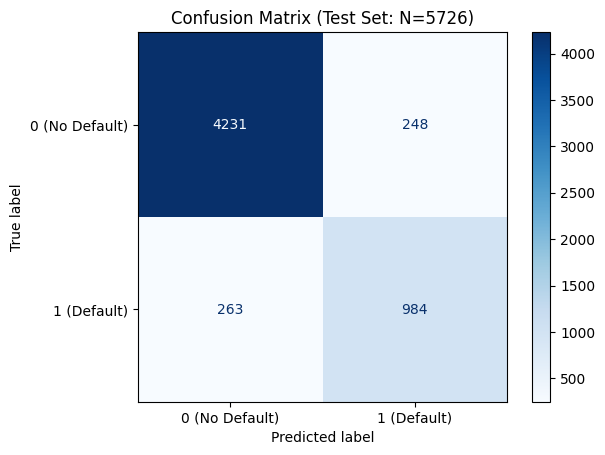

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (No Default)", "1 (Default)"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

c:\Users\damar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


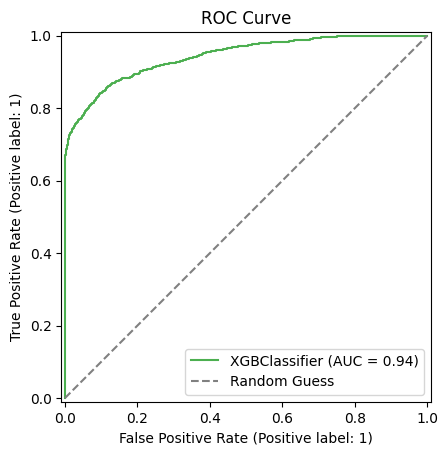

In [27]:
RocCurveDisplay.from_estimator(model, X_test, y_test, color="#4CAF50")
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.legend()
plt.show()

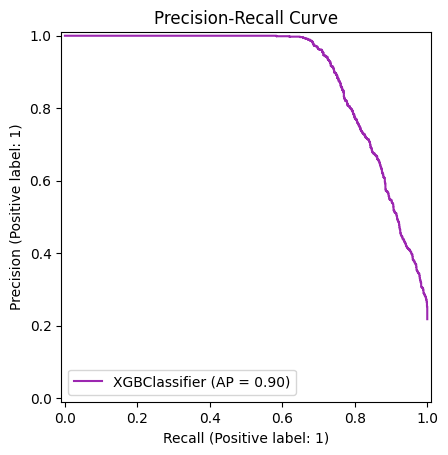

In [29]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, color="#9C27B0")
plt.title("Precision-Recall Curve")
plt.show()

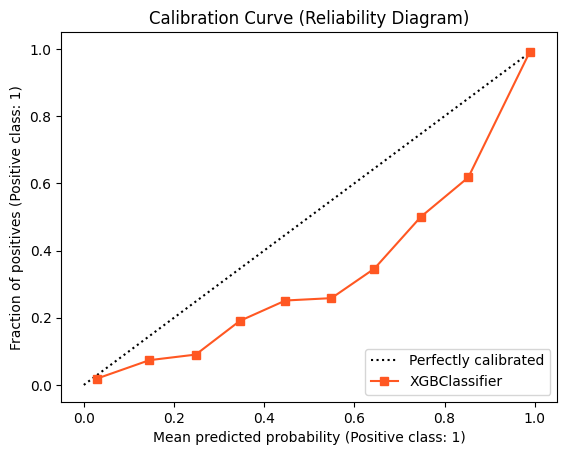

In [30]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, color='#FF5722')
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

In [31]:
os.makedirs("model_save", exist_ok=True)
model_path = "model_save/xgboost.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model successfully saved to {model_path}")

Model successfully saved to model_save/xgboost.pkl
